In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pwd

/content


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks/SW엔지니어

/content/drive/MyDrive/Colab Notebooks/SW엔지니어


#### 목표
- 손글씨 데이터를 분류하는 딥러닝 모델을 설계해보자
- 다중분류 딥러닝 모델

In [4]:
# 기본라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

데이터 로딩

In [5]:
# keras 내부에서 제공해주는 손글씨 데이터 불러오기!
from tensorflow.keras.datasets import mnist

In [6]:
(a,b),(c,d) = ([1,2],[3,4]),([5,6],[7,8])
c

[5, 6]

In [7]:
# 훈련용 데이터, 테스트 데이터 모두 나뉘어져 있음. 한번에 다운로드해서 저장
(X_train, y_train),(X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
from re import X
# 데이터 크기 확인
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
# 학습용 데이터 6만장, 테스트용 데이터 1만장
# 28*28 픽셀을 가진다.

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [9]:
# 정답데잍터 확인
np.unique(y_train)
# 0~9 손글씨 데이터
# 클래스 10개 -> 다중분류
# 0~9까지의 숫자 중 하나를 예측하는 모델링을 진행

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

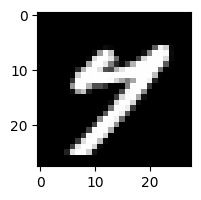

In [10]:
# 사진데이터 확인
plt.figure(figsize=(2,2))
plt.imshow(X_train[1001], cmap='gray') # 1002번째 데이터

In [11]:
X_train[1001]
# 흑백사진 (0~255)
# 0 : 검은색
# 255 : 흰색

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,  13,
          7,   0,   0,   0,   0,   0,   0,   2,  93, 244, 207,   8,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  15, 157, 254,
        197,   0,   0,   0,   0,   0,  18, 131, 254, 254, 248,  11,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   9, 220, 254, 254,
        230, 104,   0,   0,   0,  65, 216, 254, 254, 254, 218,   8,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 169, 254, 254, 231,
        126,  40,  11,  70, 180, 254, 254, 254, 254, 254,  90,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  40, 183, 251, 254, 226,  81,
         70, 180, 229, 254, 254, 254, 254, 254, 254, 115,   3,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   7, 208, 254, 254, 255, 254, 254,
        254, 255, 254, 254, 254, 254, 254, 254, 190,   3,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  53, 254, 254, 254, 254, 254, 253,
        250, 212, 169, 125, 167, 254, 254, 241,  35,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 150, 254, 254, 181,  77,  77,  48,
          0,   0,   0, 128, 254, 254, 253,  57,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  14, 157, 195,  29,   0,   0,   0,
          0,   0,  75, 248, 254, 254, 139,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  59, 217, 254, 254, 170,  15,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         15, 217, 254, 254, 214,  15,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   5,
        113, 254, 254, 238,  55,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,  89,
        254, 254, 239,  81,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 141, 254,
        254, 240, 106,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  66, 252, 254,
        252, 145,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  68, 250, 254, 252,
        171,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  54, 249, 254, 254, 210,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  56, 223, 254, 254, 189,  11,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  6

In [12]:
y_train[1001] # 라벨링된 데이터가 정답데이터에 들어있음

np.uint8(7)

#### MLP 모델링
- 입력층의 구조, 출력층 구조 (다중분류)
- 학습능력을 위한 중간층의 깊이 고려
- loss, cptimizer 설정
- 학습결과 시각화를 통한 일반화 판단

In [13]:
# 라이브러리 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Flatten

# Flatten : 2차원의 사진데이터(28,28)를 1차원으로 표현해주기 위한 클래스
# 현재 우리의 데이터셋 (28,28) 2차원 형태 -> 1차원(선형모델을 돌리기 위해)

In [14]:
# 1. 모델 설계
# 뼈대
model = Sequential()

# 입력층
model.add(InputLayer(input_shape=(28,28))) # 2차원 데이터

# 중간층
model.add(Flatten()) # 1차원으로 펼쳐주는 클래스 (선형모델작업을 위해)
model.add(Dense(units = 16, activation='sigmoid'))
model.add(Dense(units = 8, activation='sigmoid'))

# 출력층
model.add(Dense(units = 10, activation='softmax')) # units은 클래스의 개수만큼

# 다중분류시 출력층에서 사용하는 활성화 함수 : softmax
# softmax : 각각의 확률값(클래스 개수만큼의 확률값)을 총합이 10이 되도록 변환해주는 함수

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [15]:
# 모델 학습방법 및 평가 설정
model.compile(loss='categorical_crossentropy',# 다중분류
              optimizer='SGD',
              metrics=['accuracy']
              )

In [16]:
# 모델 학습
h = model.fit(X_train, y_train,
              validation_split=0.2,
              epochs=20,
              batch_size= 32 ### 디폴트값 32
              )

# 오류 확인 -> 정답데이터의 shape가 일치하지 않음
# y_train 형태를 확인해보니, 1개의 결과값(0~9 클래스 중 하나)
# 모델링 출력 결과 : 10개의 클래스에 대한 각각의 확률값

# 모델 출력값 : 10개
# 정답값 : 1개

Epoch 1/20


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(32,), output.shape=(32, 10)

In [ ]:
y_train[0]

In [ ]:
# 문제 해결 방법
# 방법 1 : 정답데이터의 형태를 원-핫 인코딩
# 방법 2 : compile단계에서 loss 함수 변경!
 # sparse_categorical_crossentropy는 정답 데이터를 자동으로 인코딩하여 계산

In [ ]:
# 방법 1 : 정답데이터의 형태를 원-핫 인코딩
# 모델의 예측값은 클래스의 개수만큼의 확률값으로 출력되기에, 정답 데이터를 원핫인코딩된 형태로 변경

from tensorflow.keras.utils import to_categorical

# to_categorical : 정수형 라벨을 원핫 인코딩된 벡터로 변환하는 도구
# 각 클래스를 벡터로 표현하며, 해당 클래스에 해당하는 인덱스 위치에 1, 나머지에 0

y_train_one_hot = to_categorical(y_train)
y_train_one_hot[45]

In [ ]:
y_train[45]

In [ ]:
h = model.fit(X_train, y_train_one_hot,
              validation_split=0.2,
              epochs=20,
              batch_size= 32 ### 디폴트값 32
              )

In [ ]:
# 방법 2 compile에서 loss 변경!
model.compile(loss='sparse_categorical_crossentropy', # 다중분류
              optimizer='SGD',
              metrics=['accuracy']
              )

In [ ]:
# 학습
h = model.fit(X_train, y_train,
              validation_split = 0.2,
              epochs=20
              )

In [ ]:
# 평가
model.evaluate(X_test, y_test)
# 최종 평가 정확도 : 약 82%

In [ ]:
# 시각화
plt.figure(figsize=(12,8))
plt.plot(h.history['accuracy'], label='acc')
plt.plot(h.history['val_accuracy'], label='val_acc')
plt.legend() # 범례
plt.show()


In [ ]:
# 더 깊게 은닉층을 쌓아보자

# 1. 모델 설계
# 뼈대
model = Sequential()

# 입력층
model.add(InputLayer(input_shape=(28,28))) # 2차원 데이터

# 중간층
model.add(Flatten()) # 1차원으로 펼쳐주는 클래스 (선형모델작업을 위해)
model.add(Dense(units = 64, activation='sigmoid'))
model.add(Dense(units = 128, activation='sigmoid'))
model.add(Dense(units = 256, activation='sigmoid'))
model.add(Dense(units = 128, activation='sigmoid'))
model.add(Dense(units = 64, activation='sigmoid'))

# 출력층
model.add(Dense(units = 10, activation='softmax')) # units은 클래스의 개수만큼

# 2. 학습 방법 및 평가방법 설정
model.compile(loss='sparse_categorical_crossentropy',# 다중분류
              optimizer='SGD',
              metrics=['accuracy']
              )

# 3. 학습
h = model.fit(X_train, y_train,
              validation_split = 0.2,
              epochs = 20, batch_size = 64)
# 배치사이즈
# 모델이 한번에 학습하는 데이터 샘플의 개수
# 전체 데이터셋을 한번에 학습할 경우 메모리문제 발생
# 데이터셋을 작은 단위로 나누어 모델에 입력, 이 단위를 배치
# 배치사이즈 기본값 : 32
# 주로 32, 64
# 32가 더 느리지만, 일반화에 조금 더 유리

# 4. 평가
model.evaluate(X_test, y_test)

In [ ]:
# 시각화
plt.figure(figsize=(12,8))
plt.plot(h.history['accuracy'], label='acc')
plt.plot(h.history['val_accuracy'], label='val_acc')
plt.legend() # 범례
plt.show()


### 활성화함수, 최적화함수 조합에 따른 성능 비교
- 손글씨 데이터
1. sigmoid + SGD 조합
2. relu + SGD 조합
3. relu + Adam 조합

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam

In [ ]:
# 1. 신경망 구조설계 (model1, model2, model3)
# 입력층
# 중간층(5개 층)
# 출력층

# 2. 학습방법 및 평가방법 설정
# optimizer =

# 3. 학습 (h1= , h2, h3)

# 4. 평가

In [ ]:
# 1. sig + SGD
# 더 깊게 은닉층을 쌓아보자

# 1. 모델 설계
# 뼈대
model1 = Sequential()

# 입력층
model1.add(InputLayer(input_shape=(28,28))) # 2차원 데이터

# 중간층
model1.add(Flatten()) # 1차원으로 펼쳐주는 클래스 (선형모델작업을 위해)
model1.add(Dense(units = 64, activation='sigmoid'))
model1.add(Dense(units = 128, activation='sigmoid'))
model1.add(Dense(units = 256, activation='sigmoid'))
model1.add(Dense(units = 128, activation='sigmoid'))
model1.add(Dense(units = 64, activation='sigmoid'))

# 출력층
model1.add(Dense(units = 10, activation='softmax')) # units은 클래스의 개수만큼

# 2. 학습 방법 및 평가방법 설정
model1.compile(loss='sparse_categorical_crossentropy',# 다중분류
              optimizer='SGD',
              metrics=['accuracy']
              )

# 3. 학습
h1 = model1.fit(X_train, y_train,
              validation_split = 0.2,
              epochs = 20)
# 배치사이즈
# 모델이 한번에 학습하는 데이터 샘플의 개수
# 전체 데이터셋을 한번에 학습할 경우 메모리문제 발생
# 데이터셋을 작은 단위로 나누어 모델에 입력, 이 단위를 배치
# 배치사이즈 기본값 : 32
# 주로 32, 64
# 32가 더 느리지만, 일반화에 조금 더 유리

# 4. 평가
model1.evaluate(X_test, y_test)

In [ ]:
# 2. relu + SGD
# 더 깊게 은닉층을 쌓아보자

# 1. 모델 설계
# 뼈대
model2 = Sequential()

# 입력층
model2.add(InputLayer(input_shape=(28,28))) # 2차원 데이터

# 중간층
model2.add(Flatten()) # 1차원으로 펼쳐주는 클래스 (선형모델작업을 위해)
model2.add(Dense(units = 64, activation='relu'))
model2.add(Dense(units = 128, activation='relu'))
model2.add(Dense(units = 256, activation='relu'))
model2.add(Dense(units = 128, activation='relu'))
model2.add(Dense(units = 64, activation='relu'))

# 출력층
model2.add(Dense(units = 10, activation='softmax')) # units은 클래스의 개수만큼

# 2. 학습 방법 및 평가방법 설정
model2.compile(loss='sparse_categorical_crossentropy',# 다중분류
              optimizer= SGD(learning_rate = 0.001),
              metrics=['accuracy']
              )

# SGD 기본 학습률은 0.01
# 학습률이 너무 큰 경우 오차가 큰 값이 그대로 전달되면서 변동이 크다
# relu함수의 경우 오차가 줄어들지 않을수가 있음.
# 3. 학습
h2 = model2.fit(X_train, y_train,
              validation_split = 0.2,
              epochs = 20)
# 배치사이즈
# 모델이 한번에 학습하는 데이터 샘플의 개수
# 전체 데이터셋을 한번에 학습할 경우 메모리문제 발생
# 데이터셋을 작은 단위로 나누어 모델에 입력, 이 단위를 배치
# 배치사이즈 기본값 : 32
# 주로 32, 64
# 32가 더 느리지만, 일반화에 조금 더 유리

# 4. 평가
model2.evaluate(X_test, y_test)

In [ ]:
# 3. relt + Adam
# 더 깊게 은닉층을 쌓아보자

# 1. 모델 설계
# 뼈대
model3 = Sequential()

# 입력층
model3.add(InputLayer(input_shape=(28,28))) # 2차원 데이터

# 중간층
model3.add(Flatten()) # 1차원으로 펼쳐주는 클래스 (선형모델작업을 위해)
model3.add(Dense(units = 64, activation='relu'))
model3.add(Dense(units = 128, activation='relu'))
model3.add(Dense(units = 256, activation='relu'))
model3.add(Dense(units = 128, activation='relu'))
model3.add(Dense(units = 64, activation='relu'))

# 출력층
model3.add(Dense(units = 10, activation='softmax')) # units은 클래스의 개수만큼

# 2. 학습 방법 및 평가방법 설정
model3.compile(loss='sparse_categorical_crossentropy',# 다중분류
              optimizer=Adam(learning_rate = 0.001),
              metrics=['accuracy']
              )

# 3. 학습
h = model3.fit(X_train, y_train,
              validation_split = 0.2,
              epochs = 20)
# 배치사이즈
# 모델이 한번에 학습하는 데이터 샘플의 개수
# 전체 데이터셋을 한번에 학습할 경우 메모리문제 발생
# 데이터셋을 작은 단위로 나누어 모델에 입력, 이 단위를 배치
# 배치사이즈 기본값 : 32
# 주로 32, 64
# 32가 더 느리지만, 일반화에 조금 더 유리

# 4. 평가
model3.evaluate(X_test, y_test)

In [ ]:
# h1, h2, h3 시각화
plt.figure(figsize=(15,5))

# sig + SGD
#plt.plot(h1.history['accuracy'], label='sig+SGD_acc')
#plt.plot(h1.history['val_accuracy'], label='sig+SGD_val_acc')
# relu + SGD
plt.plot(h2.history['accuracy'], label='relu+SGD_acc')
plt.plot(h2.history['val_accuracy'], label='relu+SGD_val_acc')
# relu + Adam
plt.plot(h.history['accuracy'], label='relu+Adam_acc')
plt.plot(h.history['val_accuracy'], label='relu+Adam_val_acc')

plt.legend()
plt.show()

# sig + SGD : 비교적 낮은 학습 속도와 정확도를 보임

# Relu + SGD : 빠른 학습 속도와 높은 정확도를 보임. Relu함수의 효과를 잘 보여줌

# Relu + Adam : 가장 빠른 학습 속도와 높은 정확도를 보임.
# Adam의 적응형 학습률 효과 덕분에 매우 효과적으로 학습이 진행된 것으로 보인다.



#### callback함수

모델저장 및 조기학습중단
- 모델저장(ModelCheckpoint):딥러닝 모델학습시 지정된 epochs를 다 끝내는 경우 과대적합이 발생할 수 있음.
-> 중간에 일반화된 모델 따로 저장할 수 있는 기능

- 조기학습중단(EarlyStopping) : epochs를 크게 설정할 경우 일정횟수 이후로는 모델의 성능이 개선되지 않을 수 있다. - 시간낭비
-> 모델의 성능이 더이상 개선되지 않는 경우에, 조기학습중단 기능

In [ ]:
# 학습된 모델 저장하기
model3.save('./data/hand_model.keras')
# keras는 모델 저장할 때 (.h5. .hdf5)를 사용해 왔지만,
# 최근에는 keras 자체의 새로운 파일 형식(.keras)를 사용하는것을 권장

In [17]:
from tensorflow.keras.datasets import mnist
(X_train, y_train),(X_test, y_test) = mnist.load_data()

In [18]:
# 저장된 모델 불러오기
from tensorflow.keras.models import load_model
load_model = load_model('./data/hand_model.keras')

In [19]:
X_test[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  84, 185, 159, 151,  60,  36,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 222, 254, 254, 254, 254, 241, 198,
        198, 198, 198, 198, 198, 198, 198, 170,  52,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  67, 114,  72, 114, 163, 227, 254,
        225, 254, 254, 254, 250, 229, 254, 254, 140,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  17,  66,
         14,  67,  67,  67,  59,  21, 236, 254, 106,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,  83, 253, 209,  18,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  22, 233, 255,  83,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 129, 254, 238,  44,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  59, 249, 254,  62,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0, 133, 254, 187,   5,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   9, 205, 248,  58,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 126, 254, 182,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  75, 251, 240,  57,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         19, 221, 254, 166,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
        203, 254, 219,  35,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38,
        254, 254,  77,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  31, 224,
        254, 115,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 133, 254,
        254,  52,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [20]:
# 학습된 모델 불러와서 사용
load_model.predict(X_test)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([1.0062072e-12, 4.0813280e-08, 8.6131295e-06, 8.0190063e-08,
       1.4080564e-14, 7.2812927e-06, 1.1496933e-33, 9.9675989e-01,
       9.2997532e-10, 3.2241857e-03], dtype=float32)

In [21]:
np.round(load_model.predict(X_test)[0],2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.], dtype=float32)

In [24]:
load_model.predict(X_test)[0].argmax()
# .argmax() 가장 큰 값의 인덱스 위치를 반환

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


np.int64(7)

In [25]:
# 학습 중단의 기능(EariyStopping) -> epochs : 10000 이여도 중간에 확인해보고 학습이 잘 안되면 학습 중단
# 중간 모델 저장 기능(ModelCheckpoint) -> 모든 모델, 좋았던 모델만 저장


In [26]:
# 모델 저장 폴더 및 저장 파일명 지정
# epoch:03d = 학습의 순서 차수, d는 10진 정수에 대한 자리 표시자
# 03 정수가 3자리 길이로 구성되야한다. ex) 1 -> 001 , 2 -> 002

# val_accuracy:.4f : 검증 정확도를 소수점 넷째짜리까지 표현
modelpath = './data/hand_model-{epoch:03d}-{val_accuracy:.4f}.keras'

In [32]:
# 전보다 나은 정확도를 보이면 저장
model_checkpoint_callback = ModelCheckpoint(filepath=modelpath, # 파일이 저장될 경로
                                   monitor='val_accuracy', # 검증 정확도를 기준으로 나아진걸 판단
                                   verbose=1, #  # 과정 출력
                                   save_best_only=True) # 더 나아진 결과만 저장 /False라면 모든 epoch마다 저장

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [30]:
# 전보다 나아지지 않으면 학습 중단
early_stopping_callback = EarlyStopping(monitor='val_accuracy',
                                        patience=5) # 전보다 나아지지 않아도 실행할 횟수 /// 5번의 에포크 동안 향상되지 않으면 학습 중단

In [31]:
# 필요한 라이브러리 임포트
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Flatten # 2차원을 1차원으로 바꾸는 라이브러리
from tensorflow.keras.optimizers import SGD, Adam

# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:

# 뼈대
model4 = Sequential()

# 입력층
model4.add(InputLayer(input_shape=(28,28))) # 2차원 데이터

# 중간층
model4.add(Flatten()) # 1차원으로 펼쳐주는 클래스 (선형모델작업을 위해)
model4.add(Dense(units = 64, activation='relu'))
model4.add(Dense(units = 128, activation='relu'))
model4.add(Dense(units = 256, activation='relu'))
model4.add(Dense(units = 128, activation='relu'))
model4.add(Dense(units = 64, activation='relu'))

# 출력층
model4.add(Dense(units = 10, activation='softmax')) # units은 클래스의 개수만큼

# 2. 학습 방법 및 평가방법 설정
model4.compile(loss='sparse_categorical_crossentropy',# 다중분류
              optimizer=Adam(learning_rate = 0.001),
              metrics=['accuracy']
              )

# 3. 학습
h = model4.fit(X_train, y_train,
              validation_data = (X_test, y_test),
              callbacks=[early_stopping_callback, model_checkpoint_callback],

              epochs =50)
# 배치사이즈
# 모델이 한번에 학습하는 데이터 샘플의 개수
# 전체 데이터셋을 한번에 학습할 경우 메모리문제 발생
# 데이터셋을 작은 단위로 나누어 모델에 입력, 이 단위를 배치
# 배치사이즈 기본값 : 32
# 주로 32, 64
# 32가 더 느리지만, 일반화에 조금 더 유리

# 4. 평가
model4.evaluate(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/50
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7993 - loss: 1.0554
Epoch 1: val_accuracy improved from -inf to 0.93810, saving model to ./data/hand_model-001-0.9381.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7994 - loss: 1.0548 - val_accuracy: 0.9381 - val_loss: 0.2127
Epoch 2/50
1868/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9441 - loss: 0.1941
Epoch 2: val_accuracy improved from 0.93810 to 0.94620, saving model to ./data/hand_model-002-0.9462.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9441 - loss: 0.1940 - val_accuracy: 0.9462 - val_loss: 0.1758
Epoch 3/50
1867/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9570 - loss: 0.1493
Epoch 3: val_accuracy improved from 0.94620 to 0.95430, saving model to ./data/hand_model-003-0.9543.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9570 - loss: 0.1494 - val_accuracy: 0.9543 - val_loss: 0.1604
Epoch 4/50
1864/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc

[0.1959151029586792, 0.97079998254776]

In [34]:
import PIL.Image as pimg # 사진파일 다루는 라이브러리

img = pimg.open('./data/손글씨.gif')
img

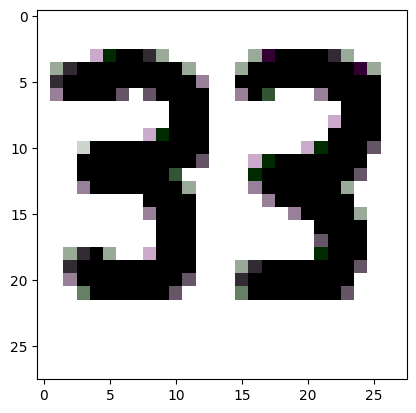

In [35]:
plt.imshow(img)
plt.show()

In [36]:
X_train[4]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  55,
        148, 210, 253, 253, 113,  87, 148,  55,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  87, 232,
        252, 253, 189, 210, 252, 252, 253, 168,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,  57, 242, 252,
        190,  65,   5,  12, 182, 252, 253, 116,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  96, 252, 252, 183,
         14,   0,   0,  92, 252, 252, 225,  21,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 132, 253, 252, 146,  14,
          0,   0,   0, 215, 252, 252,  79,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 126, 253, 247, 176,   9,   0,
          0,   8,  78, 245, 253, 129,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  16, 232, 252, 176,   0,   0,   0,
         36, 201, 252, 252, 169,  11,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  22, 252, 252,  30,  22, 119, 197,
        241, 253, 252, 251,  77,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  16, 231, 252, 253, 252, 252, 252,
        226, 227, 252, 231,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  55, 235, 253, 217, 138,  42,
         24, 192, 252, 143,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         62, 255, 253, 109,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         71, 253, 252,  21,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 253, 252,  21,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         71, 253, 252,  21,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        106, 253, 252,  21,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         45, 255, 253,  21,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 218, 252,  56,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [37]:
img

In [38]:
num = np.array(img)
num

array([[251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 196,   6,   0,   0,  49, 153, 251, 251, 251,
        251, 251, 251, 153,  43,   0,   0,   0,   0,  49, 153, 251, 251,
        251, 251],
       [251, 153,  49,   0,   0,   0,   0,   0,   0,   0,   0, 153, 251,
        251, 251, 153,   0,   0,   0,   0,   0,   0,   0,   0,  43, 153,
        251, 251],
       [251,  49,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 147,
        251, 251,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        251, 251],
       [251, 147,   0,   0,   0,   0,  98, 251,  98,   0,   0,   0,   0,
        251, 251, 147,   0,  55, 251, 251, 251, 147,   0,   0,   0,   0,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251,   0,   0,   0,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251,   0,   0,   0,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251,   0,   0,   0,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 196,   0,   0,   0,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 196,   6,   0,   0,   0,
        251, 251, 251, 251, 251, 251, 251, 251, 251,   0,   0,   0,   0,
        251, 251],
       [251, 251, 251, 202,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        251, 251, 251, 251, 251, 251, 251, 196,   6,   0,   0,   0,  98,
        251, 251],
       [251, 251, 251,   0,   0,   0,   0,   0,   0,   0,   0,   0,  98,
        251, 251, 251, 196,   6,   0,   0,   0,   0,   0,   0,   0, 251,
        251, 251],
       [251, 251, 251,   0,   0,   0,   0,   0,   0,   0,  55, 251, 251,
        251, 251, 251,   6,   0,   0,   0,   0,   0,   0,   0,  98, 251,
        251, 251],
       [251, 251, 251, 147,   0,   0,   0,   0,   0,   0,   0, 153, 251,
        251, 251, 251, 147,   0,   0,   0,   0,   0,   0, 153, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251,   0,   0,   0,   0, 251,
        251, 251, 251, 251, 147,   0,   0,   0,   0,   0,   0, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 147,   0,   0,   0, 251,
        251, 251, 251, 251, 251, 251, 147,   0,   0,   0,   0, 153, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251,   0,   0,   0, 251,
        251, 251, 251, 251, 251, 251, 251, 251,   0,   0,   0,   0, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251,   0,   0,   0, 251,
        251, 251, 251, 251, 251, 251, 251, 251,  98,   0,   0,   0, 251,
        251, 251],
       [251, 251, 153,  49,   0, 153, 251, 251, 196,   0,   0,   0, 251,
        251, 251, 251, 251, 251, 251, 251, 251,   6,   0,   0,   0, 251,
        251, 251],
       [251, 251,  49,   0,   0,   0,   0,   0,   0,   0,   0,   0, 251,
        251, 251, 153,  49,   0,   0,   0,   0,   0,   0,   0,  98, 251,
        251, 251],
       [251, 251, 147,   0,   0,   0,   0,   0,   0,   0,   0,  98, 251,
        251, 251,  49,   0,   0,   0,   0,   0,   0,   0,   0, 251, 251,
        251, 251],
       [251, 251, 251, 104,   0,   0,   0,   0,   0,   0,  98, 251, 251,
        251, 251, 104,   0,   0,   0,   0,   0,   0,   0,  98, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 25

In [39]:
# 흰색 255 : 0(검정색)으로 만들어야함
# 검정색 0 : 255(흰색)으로 만들어d야함

num = 255 - num # 색상반전
num

array([[  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,  59, 249, 255, 255, 206, 102,   4,   4,   4,
          4,   4,   4, 102, 212, 255, 255, 255, 255, 206, 102,   4,   4,
          4,   4],
       [  4, 102, 206, 255, 255, 255, 255, 255, 255, 255, 255, 102,   4,
          4,   4, 102, 255, 255, 255, 255, 255, 255, 255, 255, 212, 102,
          4,   4],
       [  4, 206, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 108,
          4,   4, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          4,   4],
       [  4, 108, 255, 255, 255, 255, 157,   4, 157, 255, 255, 255, 255,
          4,   4, 108, 255, 200,   4,   4,   4, 108, 255, 255, 255, 255,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4, 255, 255, 255,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4, 255, 255, 255,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4, 255, 255, 255,
          4,   4,   4,   4,   4,   4,   4,   4,   4,  59, 255, 255, 255,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,  59, 249, 255, 255, 255,
          4,   4,   4,   4,   4,   4,   4,   4,   4, 255, 255, 255, 255,
          4,   4],
       [  4,   4,   4,  53, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          4,   4,   4,   4,   4,   4,   4,  59, 249, 255, 255, 255, 157,
          4,   4],
       [  4,   4,   4, 255, 255, 255, 255, 255, 255, 255, 255, 255, 157,
          4,   4,   4,  59, 249, 255, 255, 255, 255, 255, 255, 255,   4,
          4,   4],
       [  4,   4,   4, 255, 255, 255, 255, 255, 255, 255, 200,   4,   4,
          4,   4,   4, 249, 255, 255, 255, 255, 255, 255, 255, 157,   4,
          4,   4],
       [  4,   4,   4, 108, 255, 255, 255, 255, 255, 255, 255, 102,   4,
          4,   4,   4, 108, 255, 255, 255, 255, 255, 255, 102,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4, 255, 255, 255, 255,   4,
          4,   4,   4,   4, 108, 255, 255, 255, 255, 255, 255,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4, 108, 255, 255, 255,   4,
          4,   4,   4,   4,   4,   4, 108, 255, 255, 255, 255, 102,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4, 255, 255, 255,   4,
          4,   4,   4,   4,   4,   4,   4,   4, 255, 255, 255, 255,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4, 255, 255, 255,   4,
          4,   4,   4,   4,   4,   4,   4,   4, 157, 255, 255, 255,   4,
          4,   4],
       [  4,   4, 102, 206, 255, 102,   4,   4,  59, 255, 255, 255,   4,
          4,   4,   4,   4,   4,   4,   4,   4, 249, 255, 255, 255,   4,
          4,   4],
       [  4,   4, 206, 255, 255, 255, 255, 255, 255, 255, 255, 255,   4,
          4,   4, 102, 206, 255, 255, 255, 255, 255, 255, 255, 157,   4,
          4,   4],
       [  4,   4, 108, 255, 255, 255, 255, 255, 255, 255, 255, 157,   4,
          4,   4, 206, 255, 255, 255, 255, 255, 255, 255, 255,   4,   4,
          4,   4],
       [  4,   4,   4, 151, 255, 255, 255, 255, 255, 255, 157,   4,   4,
          4,   4, 151, 255, 255, 255, 255, 255, 255, 255, 157,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   

In [45]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [40]:
# 차원 수정 (모델이 2차원을 입력값을 인식)

In [43]:
num = num.reshape(1,28,28)
num

array([[[  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4],
        [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4],
        [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4],
        [  4,   4,   4,   4,  59, 249, 255, 255, 206, 102,   4,   4,
           4,   4,   4,   4, 102, 212, 255, 255, 255, 255, 206, 102,
           4,   4,   4,   4],
        [  4, 102, 206, 255, 255, 255, 255, 255, 255, 255, 255, 102,
           4,   4,   4, 102, 255, 255, 255, 255, 255, 255, 255, 255,
         212, 102,   4,   4],
        [  4, 206, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
         108,   4,   4, 255, 255, 255, 255, 255, 255, 255, 255, 255,
         255, 255,   4

In [47]:
# 정답 확인하기
pred = model4.predict(num)
pred_digit = np.argmax(pred)
pred_digit

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


np.int64(5)

In [48]:
model4.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9662 - loss: 0.2232


[0.1959151029586792, 0.97079998254776]